In [1]:
import numpy as np
import torch
import matplotlib.pyplot as pyplot

In [2]:
npts = 128
mpts = 256
n = np.arange(npts, dtype=np.float64)
k = np.arange(mpts, dtype=np.float64)

dx = 0.02
x = n * dx

f0 = 3.0
f1 = 4.0
y = np.sin(2*np.pi*f0*x) * np.exp(-f0*x/2) + 0.2*np.sin(2*np.pi*f1*x)

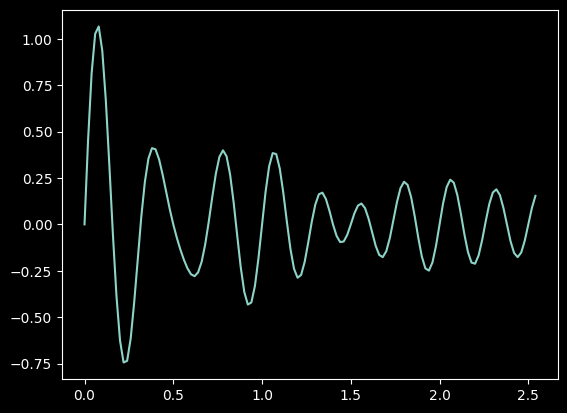

In [3]:
pyplot.plot(x, y)

In [4]:
f = np.fft.fftshift(np.fft.fftfreq(npts, d=dx))
yft = np.fft.fftshift(np.fft.fft(y))

In [5]:
fstart = 2
fstop = 6
df = (fstop - fstart) / (mpts - 1)
theta0 = fstart * dx
phi0 = -df * dx

A0 = 1.0
W0 = 1.0

In [6]:
theta0, phi0

(0.04, -0.00031372549019607844)

In [7]:
A = A0 * np.exp(2j*np.pi*theta0)
W = W0 * np.exp(2j*np.pi*phi0)

In [8]:
L = 1
while L < npts + mpts - 1:
    L *= 2
L

512

In [9]:
premult = np.power(A, -n) * np.power(W, 0.5*n*n)
m = np.arange(-(npts-1), mpts)
chirp = np.power(W, -0.5*m*m)

vn = np.zeros(L, dtype=np.complex128)
vn[:mpts] = chirp[npts-1:]
vn[L - (npts-1):] = chirp[:npts-1]
Vk = np.fft.fft(vn)

a = np.zeros(L, dtype=np.complex128)
a[:npts] = y * premult
conv = np.fft.ifft(np.fft.fft(a) * Vk)

postmult = np.power(W, 0.5*k*k)
czt = postmult * conv[:mpts]

In [10]:
f_resamp = fstart + k*df

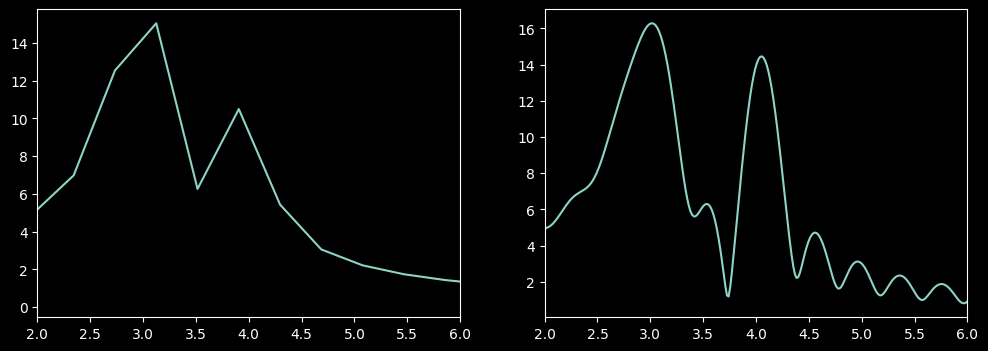

In [11]:
fig, axarr = pyplot.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axarr
ax1.plot(f, np.abs(yft))
ax2.plot(f_resamp, np.abs(czt))

for ax in axarr:
    ax.set_xlim(fstart, fstop)

In [12]:
theta0, phi0

(0.04, -0.00031372549019607844)

In [13]:
chirp

array([-0.98224105-1.87623344e-01j, -0.99816352+6.05771481e-02j,
       -0.952942  +3.03152674e-01j, -0.85073557+5.25593935e-01j,
       -0.69895882+7.15161919e-01j, -0.5076622 +8.61556202e-01j,
       -0.28879591+9.57390686e-01j, -0.05541147+9.98463604e-01j,
        0.17914564+9.83822564e-01j,  0.40200418+9.15637832e-01j,
        0.60145419+7.98907288e-01j,  0.76752065+6.41024218e-01j,
        0.89240058+4.51244057e-01j,  0.970751  +2.40088516e-01j,
        0.99982467+1.87252617e-02j,  0.97945948-2.01641077e-01j,
        0.91193485-4.10335026e-01j,  0.80171428-5.97707459e-01j,
        0.6550977 -7.55544173e-01j,  0.4798092 -8.77372859e-01j,
        0.28454687-9.58662130e-01j,  0.07852051-9.96912499e-01j,
       -0.12899922-9.91644696e-01j, -0.32909933-9.44295309e-01j,
       -0.51359411-8.58033270e-01j, -0.67533281-7.37513117e-01j,
       -0.80843728-5.88582332e-01j, -0.90846527-4.17960345e-01j,
       -0.97249919-2.32906247e-01j, -0.99916362-4.08909004e-02j,
       -0.98857759+1.5071

In [14]:
vn

array([ 1.        +0.00000000e+00j,  0.99999951+9.85597536e-04j,
        0.99999223+3.94238057e-03j,  0.99996066+8.87026293e-03j,
        0.99987566+1.57689095e-02j,  0.99969645+2.46374492e-02j,
        0.9993706 +3.54740727e-02j,  0.99883406+4.82755162e-02j,
        0.99801123+6.30364308e-02j,  0.99681501+7.97486390e-02j,
        0.99514692+9.84002783e-02j,  0.99289727+1.18974836e-01j,
        0.98994539+1.41450078e-01j,  0.98615993+1.65796870e-01j,
        0.98139925+1.91977910e-01j,  0.97551197+2.19946358e-01j,
        0.96833758+2.49644400e-01j,  0.95970726+2.81001727e-01j,
        0.94944482+3.13933971e-01j,  0.93736785+3.48341091e-01j,
        0.92328911+3.84105749e-01j,  0.90701808+4.21091686e-01j,
        0.88836282+4.59142132e-01j,  0.86713207+4.98078279e-01j,
        0.8431376 +5.37697853e-01j,  0.81619691+5.77773831e-01j,
        0.78613617+6.18053335e-01j,  0.75279349+6.58256764e-01j,
        0.71602249+6.98077211e-01j,  0.67569617+7.37180225e-01j,
        0.63171101+7.7520

In [15]:
conv

array([ 4.85304326e+00-9.76897187e-01j,  4.88305352e+00-9.49167533e-01j,
        4.92917197e+00-9.07835376e-01j,  4.99217489e+00-8.55827872e-01j,
        5.07200552e+00-7.96056939e-01j,  5.16780951e+00-7.31232863e-01j,
        5.27801136e+00-6.63698149e-01j,  5.40042413e+00-5.95289914e-01j,
        5.53238398e+00-5.27236834e-01j,  5.67089978e+00-4.60094153e-01j,
        5.81280835e+00-3.93717834e-01j,  5.95492605e+00-3.27276647e-01j,
        6.09418875e+00-2.59299013e-01j,  6.22777315e+00-1.87749811e-01j,
        6.35319437e+00-1.10131181e-01j,  6.46837631e+00-2.36006208e-02j,
        6.57169296e+00+7.49005860e-02j,  6.66198078e+00+1.88515480e-01j,
        6.73852345e+00+3.20342428e-01j,  6.80101203e+00+4.73314620e-01j,
        6.84948403e+00+6.50092665e-01j,  6.88424624e+00+8.52973772e-01j,
        6.90578612e+00+1.08381982e+00j,  6.91467692e+00+1.34400542e+00j,
        6.91148153e+00+1.63438606e+00j,  6.89665988e+00+1.95528528e+00j,
        6.87048372e+00+2.30649919e+00j,  6.83296274